In [1]:
import polars as pl
import polars.selectors as cs
from hta.trace_analysis import TraceAnalysis
import pandas as pd
import glob
import os

In [2]:
dfs = []
for path in glob.glob("/proj/threadtune-PG0/amir/kineto_traces/*"):
    analyzer = TraceAnalysis({0: "device.0.json"}, path)
    rank = 0
    trace_data = analyzer.t.get_trace(rank)
    symbol_table = analyzer.t.symbol_table.get_sym_table()
    dfs.append(
        pl.concat(
            pl.from_pandas(trace_data[trace_data["stream"] != -1])
            .select(pl.lit(rank).alias("rank"), pl.all())
            for rank, trace_data in analyzer.t.traces.items()
        ).join(
            pl.from_dict({"name": list(range(len(symbol_table))), "s_name": symbol_table}),
            on="name",
        )
    )
dfs

Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json time = 0.16 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json backend=json in 0.39 seconds; current PID:581969
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json in 0.45 seconds; current PID:581969
leaving parse_multiple_ranks duration=0.46 seconds
leaving parse_traces duration=0.46 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json time = 0.11 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt

[shape: (1_131, 22)
 ┌──────┬───────┬─────┬──────┬───┬─────────────┬───────────────────┬───────────┬────────────────────┐
 │ rank ┆ index ┆ cat ┆ name ┆ … ┆ external_id ┆ index_correlation ┆ iteration ┆ s_name             │
 │ ---  ┆ ---   ┆ --- ┆ ---  ┆   ┆ ---         ┆ ---               ┆ ---       ┆ ---                │
 │ i32  ┆ i16   ┆ i64 ┆ i64  ┆   ┆ i16         ┆ i16               ┆ i8        ┆ str                │
 ╞══════╪═══════╪═════╪══════╪═══╪═════════════╪═══════════════════╪═══════════╪════════════════════╡
 │ 0    ┆ 13921 ┆ 96  ┆ 179  ┆ … ┆ 7           ┆ 13923             ┆ 0         ┆ Memset (Device)    │
 │ 0    ┆ 13938 ┆ 50  ┆ 75   ┆ … ┆ 7           ┆ 13940             ┆ 0         ┆ void implicit_conv │
 │      ┆       ┆     ┆      ┆   ┆             ┆                   ┆           ┆ olve_sgemm<f…      │
 │ 0    ┆ 13945 ┆ 50  ┆ 61   ┆ … ┆ 10          ┆ 13947             ┆ 0         ┆ void at::native::e │
 │      ┆       ┆     ┆      ┆   ┆             ┆              

In [3]:
analyzer = TraceAnalysis({0: "device.0.json"}, "/proj/threadtune-PG0/amir/kineto_traces/bert-inference/")
rank = 0
trace_data = analyzer.t.get_trace(rank)
symbol_table = analyzer.t.symbol_table.get_sym_table()
trace_df = pl.concat(
    pl.from_pandas(trace_data[trace_data["stream"] != -1][["name", "dur"]])
    .select(pl.lit(rank).alias("rank"), pl.all())
    for rank, trace_data in analyzer.t.traces.items()
).join(
    pl.from_dict({"name": list(range(len(symbol_table))), "s_name": symbol_table}),
    on="name",
).filter(
    ~pl.col("s_name").str.starts_with("nccl") & 
    ~pl.col("s_name").is_in([
        "Stream Sync",
        "Memcpy DtoD (Device -> Device)",
        "Memcpy HtoD (Pageable -> Device)",
        "Memcpy DtoH (Device -> Pinned)",
    ])
).select(pl.lit("bert").alias("model"), pl.all())
trace_df

Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json time = 0.01 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json backend=json in 0.06 seconds; current PID:581969


Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/bert-inference/device.0.json in 0.08 seconds; current PID:581969
leaving parse_multiple_ranks duration=0.08 seconds
leaving parse_traces duration=0.09 seconds
There is only one iteration in the trace. The analysis result may not be accurate.


model,rank,name,dur,s_name
str,i32,i64,f64,str
"""bert""",0,65,9.0,"""void at::native::(anonymous na…"
"""bert""",0,65,4.0,"""void at::native::(anonymous na…"
"""bert""",0,5,1.0,"""void at::native::vectorized_el…"
"""bert""",0,65,7.0,"""void at::native::(anonymous na…"
"""bert""",0,5,0.0,"""void at::native::vectorized_el…"
…,…,…,…,…
"""bert""",0,14,7.0,"""void gemv2T_kernel_val<int, in…"
"""bert""",0,32,2.0,"""void at::native::vectorized_el…"
"""bert""",0,27,3.0,"""void at::native::(anonymous na…"


In [4]:
accel_df = pl.read_csv(
    "/users/zarand1a/accel-sim-framework/kernel_times.csv",
).select(
    pl.col("benchmark").alias("model"),
    pl.col("kernel_demangled").str.strip_chars().alias("kernel"),
    (pl.col("cycle") / 1132).alias("accel_time_us"),
)

In [5]:
accel_df.filter(pl.col("model") == "bert").write_csv("accel_time.csv")

In [6]:
accel_df.filter(pl.col("model") == "bert")

model,kernel,accel_time_us
str,str,f64
"""bert""","""void at::native::<unnamed>::in…",9.166078
"""bert""","""void at::native::<unnamed>::in…",7.567138
"""bert""","""void at::native::vectorized_el…",5.09894
"""bert""","""void at::native::<unnamed>::in…",9.189046
"""bert""","""void at::native::vectorized_el…",5.09894
…,…,…
"""bert""","""void at::native::vectorized_el…",4.864841
"""bert""","""void at::native::vectorized_el…",5.137809
"""bert""","""void at::native::vectorized_el…",4.948763


In [7]:
(trace_data["cat"] == 33).sum()

np.int64(0)

In [8]:
accel_df.join(
    trace_df.select("model", pl.col("s_name").alias("kernel"), pl.col("dur").alias("trace_time_us")),
    on=["model", "kernel"],
)

model,kernel,accel_time_us,trace_time_us
str,str,f64,f64
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.839223,27.0
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.839223,31.0
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.839223,27.0
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.839223,26.0
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.839223,26.0
…,…,…,…
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.934629,28.0
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.934629,28.0
"""bert""","""volta_sgemm_128x32_sliced1x4_t…",33.934629,27.0


In [9]:
trace_df.select("model", pl.col("s_name").alias("kernel"), pl.col("dur").alias("trace_time_us")).write_csv("trace_time.csv")

Accel Data Head:
shape: (5, 3)
┌───────┬─────────────────────────────────┬───────────────┐
│ model ┆ kernel                          ┆ accel_time_us │
│ ---   ┆ ---                             ┆ ---           │
│ str   ┆ str                             ┆ f64           │
╞═══════╪═════════════════════════════════╪═══════════════╡
│ bert  ┆ void at::native::<unnamed>::in… ┆ 9.166078      │
│ bert  ┆ void at::native::<unnamed>::in… ┆ 7.567138      │
│ bert  ┆ void at::native::vectorized_el… ┆ 5.09894       │
│ bert  ┆ void at::native::<unnamed>::in… ┆ 9.189046      │
│ bert  ┆ void at::native::vectorized_el… ┆ 5.09894       │
└───────┴─────────────────────────────────┴───────────────┘
Trace Data Head:
shape: (5, 3)
┌───────┬─────────────────────────────────┬───────────────┐
│ model ┆ kernel                          ┆ trace_time_us │
│ ---   ┆ ---                             ┆ ---           │
│ str   ┆ str                             ┆ f64           │
╞═══════╪═════════════════════════════

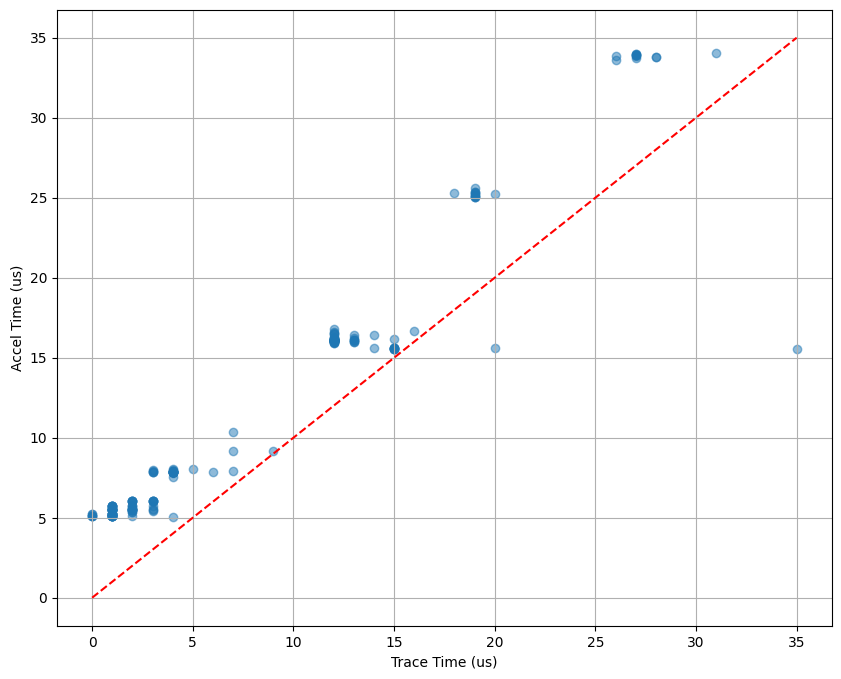

In [10]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Load the dataframes
df_accel = pl.read_csv("accel_time.csv")
df_trace = pl.read_csv("trace_time.csv")

# Inspect the data
print("Accel Data Head:")
print(df_accel.head())
print("Trace Data Head:")
print(df_trace.head())

# Determine the minimum length to trim the extra kernels
min_len = min(len(df_accel), len(df_trace))
print(f"Trimming to length: {min_len}")

# Slice the dataframes to match serially
df_accel_trimmed = df_accel.slice(0, min_len)
df_trace_trimmed = df_trace.slice(0, min_len)

# Extract the time columns
accel_times = df_accel_trimmed["accel_time_us"]
trace_times = df_trace_trimmed["trace_time_us"]

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(trace_times, accel_times, alpha=0.5, label='Kernels')

# Add y=x line
# Get the range for the line
max_val = max(accel_times.max(), trace_times.max())
min_val = min(accel_times.min(), trace_times.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.xlabel('Trace Time (us)')
plt.ylabel('Accel Time (us)')
plt.grid(True)
plt.savefig('accel_vs_trace_comparison.png')
print("Plot saved to accel_vs_trace_comparison.png")

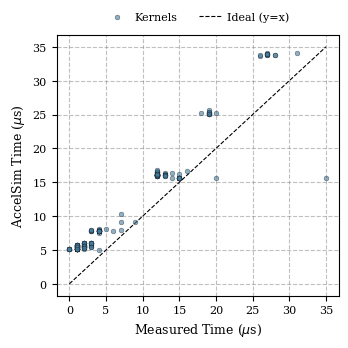

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SINGLE-COLUMN STYLE CONFIGURATION ---
# Matches your bar chart reference exactly
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.figsize": (3.4, 3.4), 
    "figure.autolayout": True
})

# --- 2. DATA PREPARATION ---
# Load the dataframes
df_accel = pl.read_csv("accel_time.csv")
df_trace = pl.read_csv("trace_time.csv")

# Determine the minimum length to trim the extra kernels
min_len = min(len(df_accel), len(df_trace))

# Slice the dataframes to match serially
df_accel_trimmed = df_accel.slice(0, min_len)
df_trace_trimmed = df_trace.slice(0, min_len)

# Extract the time columns
accel_times = df_accel_trimmed["accel_time_us"]
trace_times = df_trace_trimmed["trace_time_us"]

# --- 3. PLOTTING ---
fig, ax = plt.subplots()

# Use the darker blue from your palette for the dots
primary_color = "#457b9d" 

# Create the scatter plot
# s=12 makes markers small enough for a 3.4" wide figure
sns.scatterplot(
    x=trace_times, 
    y=accel_times, 
    ax=ax,
    color=primary_color,
    alpha=0.6,             # Transparency helps if points overlap
    edgecolor="black",     # Thin border like the bars
    linewidth=0.3, 
    s=12,                  # Marker size tailored for small column width
    label="Kernels",
    zorder=2               # Ensure dots are above grid
)

# --- 4. REFERENCE LINE (y=x) ---
# Calculate range for the line
max_val = max(accel_times.max(), trace_times.max())
min_val = min(accel_times.min(), trace_times.min())

# Use a dashed black line to match the "serif" aesthetic (red is often too aggressive for papers)
ax.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color='black', 
    linestyle='--', 
    linewidth=0.8, 
    label='Ideal (y=x)',
    zorder=1
)

# --- 5. FINE TUNING LAYOUT ---
# Enable grid for both axes (useful for scatter), matching the style of the bar chart
ax.grid(which='major', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Labels
ax.set_xlabel("Measured Time ($\mu$s)") # Using LaTeX formatting for micro symbol
ax.set_ylabel("AccelSim Time ($\mu$s)")

# Legend placement (Top Center, outside)
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=2, 
    frameon=False,
    borderpad=0.2,
    handletextpad=0.5
)

# Remove excess whitespace
plt.tight_layout(pad=0.5)

# Save as PDF (Vector graphic is better for papers)
plt.savefig("accel_vs_trace.pdf", dpi=300)
plt.show()